In [2]:
import pandas as pd #  pandas
import numpy as np # numpy
import matplotlib.pyplot as plt # matplotlib.pyplot
from pprint import pprint # pprint para visualización metadatos
from ucimlrepo import fetch_ucirepo # se importa fetch_ucilrepo
import seaborn as sns # seaborn
import statsmodels.api as sm #statsmodels
from sklearn.model_selection import train_test_split # para dividir los datos en train y test
from sklearn.preprocessing import StandardScaler, LabelEncoder # para estandarizar los datos
from sklearn.linear_model import LogisticRegression # RL
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score # informes de resultados
from sklearn.model_selection import GridSearchCV # para grid search
from sklearn.tree import DecisionTreeClassifier # DT
from sklearn.ensemble import RandomForestClassifier # RF
from sklearn.neighbors import KNeighborsClassifier #kNN
from sklearn.svm import SVC # SVC
from sklearn.naive_bayes import GaussianNB # GNß
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis # LDA
from sklearn.metrics import recall_score # recall
from sklearn.neural_network import MLPClassifier # MLP
import shap # SHAP
import lime
from lime import lime_tabular # LIME
import xgboost as xgb # xgboost
import os

In [3]:
# Se carga el dataset DARWIN
darwin = fetch_ucirepo(id=732)
# X (features)
x = darwin.data.features

# Y (targets)
y = darwin.data.targets

# Se concatena features y target en un mismo dataframe 'df'
df = pd.concat([x,y], axis=1)

In [4]:
"""
CARGA DE BASE DE DATOS LOCAL 
- Emplear si el servidor UCI Machine Learning Repository se cae

# ruta local
ruta_darwin = os.path.expanduser("/Users/joseromerodegaetano/Desktop/DARWIN/DARWIN.csv") 

try:

    # Se carga el dataset
    df = pd.read_csv(ruta_darwin)

    x = df.drop(columns=['class'])
    y = df['class']

    print('Dataset DARWIN cargado correctamente')

except FileNotFoundError:
    print(f"No se encuentra el archivo .csv DARWIN en {ruta_darwin}")
"""

'\nCARGA DE BASE DE DATOS LOCAL \n- Emplear si el servidor UCI Machine Learning Repository se cae\n\n# ruta local\nruta_darwin = os.path.expanduser("/Users/joseromerodegaetano/Desktop/DARWIN/DARWIN.csv") \n\ntry:\n\n    # Se carga el dataset\n    df = pd.read_csv(ruta_darwin)\n\n    x = df.drop(columns=[\'class\'])\n    y = df[\'class\']\n\n    print(\'Dataset DARWIN cargado correctamente\')\n\nexcept FileNotFoundError:\n    print(f"No se encuentra el archivo .csv DARWIN en {ruta_darwin}")\n'

In [5]:
def analizar_tarea(df, num_tarea): # función analizar_tarea
    """
    Analiza una tarea específica (1-25)
    """
    suffix = str(num_tarea) # sufijo
    
    # --- FILTRADO ---
    # Se buscan las columnas que terminen en el número de tarea, 
    # IMPORTANTE: se asegura que el número anterior NO sea otro dígito.
    cols_tarea = [] # lista vacia
    for col in df.columns: # se recorren las columnas
        if col.endswith(suffix): # cuando la col acaba en el sufijo
            # Se verifica el prefijo del número 
            posible_prefijo = col[:-(len(suffix))] # prefijo
            # si el último caracter del prefijo no es un número se añade
            if not posible_prefijo[-1:].isdigit(): 
                cols_tarea.append(col)

    if not cols_tarea: # si no se encuentran columnas con el sufijo dado
        print(f"No se encontraron columnas para la tarea {num_tarea}")
        return None

    print(f"Analizando Tarea {num_tarea} ({len(cols_tarea)} variables)")

    # Se crea un un subset con las variables de la tarea + la clase
    df_tarea = df[cols_tarea + ['class']].copy()

    print(f"Tarea {num_tarea} extraída: {len(cols_tarea)} variables + 'class'.")
    return df_tarea

    # --- EJECUCIÓN ---
df_1 = analizar_tarea(df, 1)
df_2 = analizar_tarea(df, 2)
df_3 = analizar_tarea(df, 3)
df_4 = analizar_tarea(df, 4)
df_5 = analizar_tarea(df, 5)
df_6 = analizar_tarea(df, 6)
df_7 = analizar_tarea(df, 7)
df_8 = analizar_tarea(df, 8)
df_9 = analizar_tarea(df, 9)
df_10 = analizar_tarea(df, 10)
df_11 = analizar_tarea(df, 11)
df_12 = analizar_tarea(df, 12)
df_13 = analizar_tarea(df, 13)
df_14 = analizar_tarea(df, 14)
df_15 = analizar_tarea(df, 15)
df_16 = analizar_tarea(df, 16)
df_17 = analizar_tarea(df, 17)
df_18 = analizar_tarea(df, 18)
df_19 = analizar_tarea(df, 19)
df_20 = analizar_tarea(df, 20)
df_21 = analizar_tarea(df, 21)
df_22 = analizar_tarea(df, 22)
df_23 = analizar_tarea(df, 23)
df_24 = analizar_tarea(df, 24)
df_25 = analizar_tarea(df, 25)

Analizando Tarea 1 (18 variables)
Tarea 1 extraída: 18 variables + 'class'.
Analizando Tarea 2 (18 variables)
Tarea 2 extraída: 18 variables + 'class'.
Analizando Tarea 3 (18 variables)
Tarea 3 extraída: 18 variables + 'class'.
Analizando Tarea 4 (18 variables)
Tarea 4 extraída: 18 variables + 'class'.
Analizando Tarea 5 (18 variables)
Tarea 5 extraída: 18 variables + 'class'.
Analizando Tarea 6 (18 variables)
Tarea 6 extraída: 18 variables + 'class'.
Analizando Tarea 7 (18 variables)
Tarea 7 extraída: 18 variables + 'class'.
Analizando Tarea 8 (18 variables)
Tarea 8 extraída: 18 variables + 'class'.
Analizando Tarea 9 (18 variables)
Tarea 9 extraída: 18 variables + 'class'.
Analizando Tarea 10 (18 variables)
Tarea 10 extraída: 18 variables + 'class'.
Analizando Tarea 11 (18 variables)
Tarea 11 extraída: 18 variables + 'class'.
Analizando Tarea 12 (18 variables)
Tarea 12 extraída: 18 variables + 'class'.
Analizando Tarea 13 (18 variables)
Tarea 13 extraída: 18 variables + 'class'.
Anal

In [6]:
# Se elimina la columna ID
# X = df (sin 'ID' ni 'class'), axis = 1 para cols
X = df_19.drop(['class'], axis = 1)

# Y contiene 'class'
Y = df_19['class']

# Se codficia paciente (P) -> 1 y sano (H) -> 0
le = LabelEncoder()
Y = le.fit_transform(Y)

# Se dividen los datos en 80% para train y 20% para test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

# Se revisa la correcta división de los datos
print(f"Datos de entrenamiento {len(X_train)}")
print(f"Datos test {len(X_test)}")

Datos de entrenamiento 139
Datos test 35


In [7]:
# StandardScaler()
scaler = StandardScaler()

# Se ajusta la estandarización con X_train
X_train_scaled = scaler.fit_transform(X_train)

# Se aplica la transformación al test
X_test_scaled = scaler.transform(X_test)

# ANÁLISIS DE ML 4

## DECISION TREE

In [8]:
# Se crea el modelo
tree_model = DecisionTreeClassifier(random_state=42) # random state para replicabilidad

# Se entrena el modelo
tree_model.fit(X_train_scaled, Y_train)

# Se realizan las predicciones
Y_pred_dt = tree_model.predict(X_test_scaled)

# Resultados
print(" --- INFORME DE CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred_dt))

print("--- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_dt))

# TP; TN; FP; FN
tn_dt, fp_dt, fn_dt, tp_dt = confusion_matrix(Y_test, Y_pred_dt).ravel()

sensitivity_dt = tp_dt / (tp_dt + fn_dt) # sensibilidad
print(f"Sensibilidad: {sensitivity_dt:.2f}")

specificity_dt = tn_dt / (tn_dt + fp_dt) # especificidad
print(f"Especificidad: {specificity_dt:.2f}")

 --- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.74      0.82      0.78        17
           1       0.81      0.72      0.76        18

    accuracy                           0.77        35
   macro avg       0.77      0.77      0.77        35
weighted avg       0.78      0.77      0.77        35

--- MATRIZ DE CONFUSIÓN ---
[[14  3]
 [ 5 13]]
Sensibilidad: 0.72
Especificidad: 0.82


**SHAP**

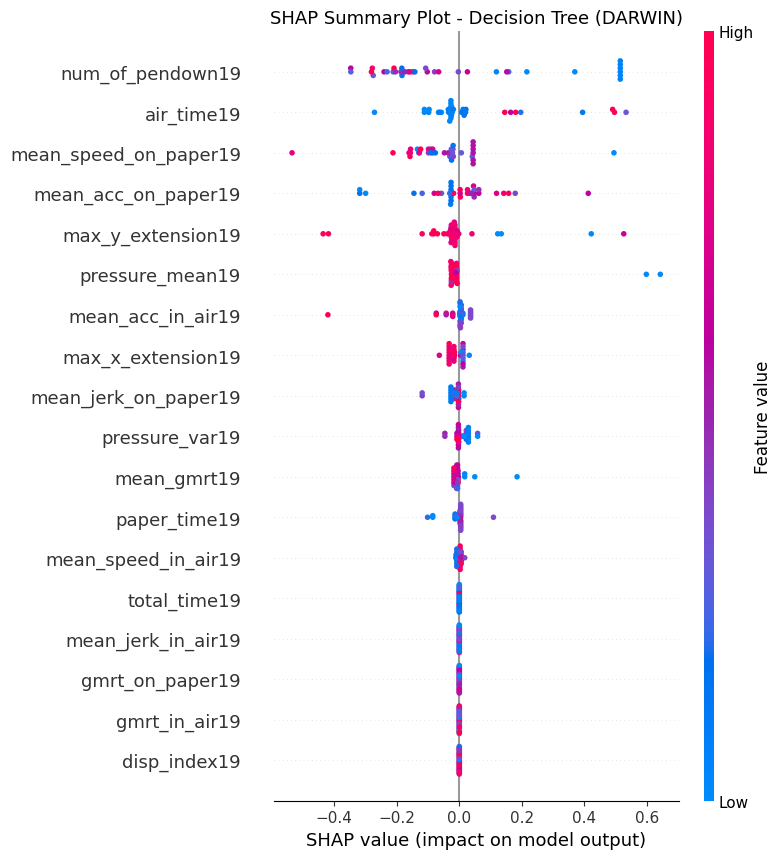

✔ Summary plot guardado.


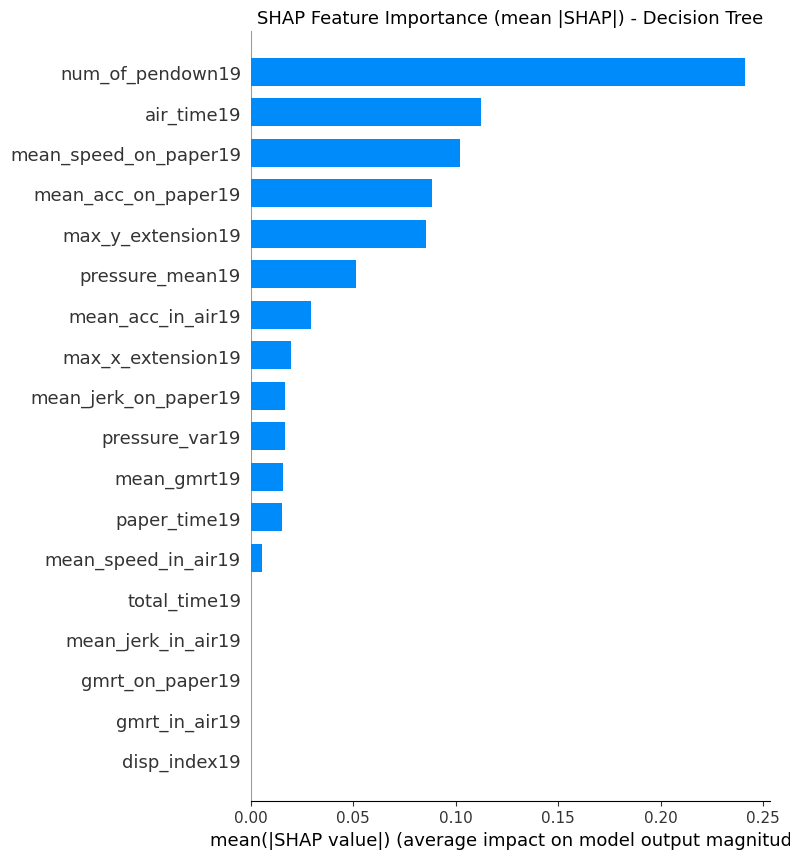

✔ Bar plot guardado.


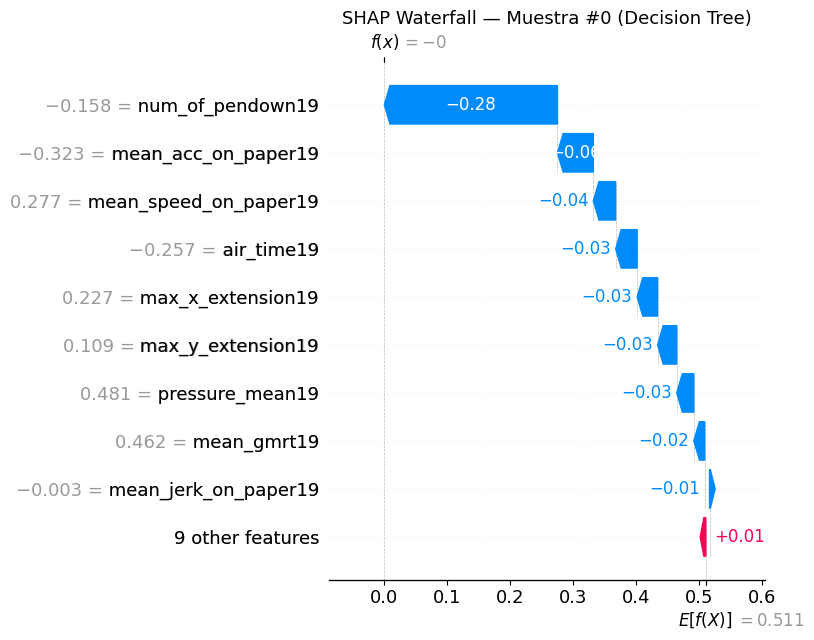

✔ Waterfall plot guardado.


<Figure size 640x480 with 0 Axes>

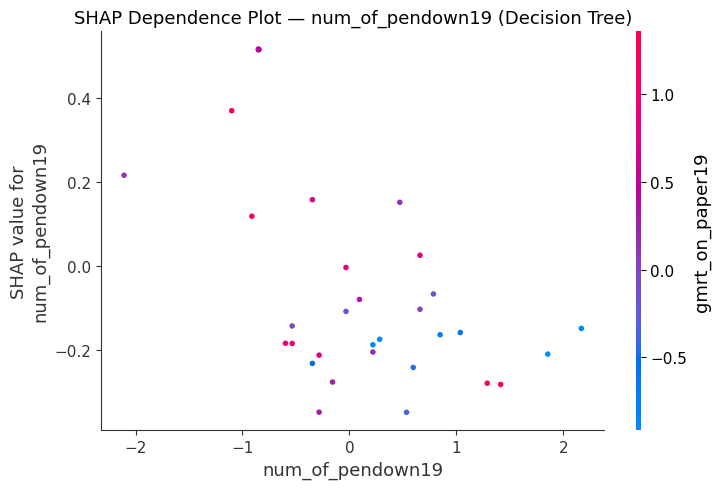

✔ Dependence plot guardado para: num_of_pendown19

=== TOP 10 FEATURES MÁS RELEVANTES (SHAP - Decision Tree) ===
              Feature  Mean |SHAP|
     num_of_pendown19     0.241224
           air_time19     0.112376
mean_speed_on_paper19     0.101949
  mean_acc_on_paper19     0.088496
    max_y_extension19     0.085472
      pressure_mean19     0.051481
    mean_acc_in_air19     0.029325
    max_x_extension19     0.019450
 mean_jerk_on_paper19     0.016760
       pressure_var19     0.016747


In [9]:
# ============================================================
# ANÁLISIS SHAP PARA DECISION TREE
# ============================================================

# Explainer
explainer_dt = shap.TreeExplainer(tree_model) # best_tree o tree_model
 
# SHAP values
shap_values_dt = explainer_dt.shap_values(X_test_scaled)

# Extraer clase positiva (Parkinson) — estructura (n_muestras, n_features, n_clases)
sv = np.array(shap_values_dt)[:, :, 1]  # shape (35, 450)

# ============================================================
# Summary Plot (Beeswarm)
# ============================================================
plt.figure()
shap.summary_plot(
    sv,
    X_test_scaled,
    feature_names=X.columns.tolist(),
    show=False
)
plt.title("SHAP Summary Plot - Decision Tree (DARWIN)", fontsize=13)
plt.tight_layout()
plt.savefig("shap_dt_summary_beeswarm.png", dpi=150, bbox_inches='tight')
plt.show()
print("✔ Summary plot guardado.")

# ============================================================
# Bar Plot
# ============================================================
plt.figure()
shap.summary_plot(
    sv,
    X_test_scaled,
    feature_names=X.columns.tolist(),
    plot_type="bar",
    show=False
)
plt.title("SHAP Feature Importance (mean |SHAP|) - Decision Tree", fontsize=13)
plt.tight_layout()
plt.savefig("shap_dt_bar_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print("✔ Bar plot guardado.")

# ============================================================
# Waterfall Plot 
# ============================================================
sample_idx = 0

explanation_dt = shap.Explanation(
    values=sv[sample_idx],
    base_values=explainer_dt.expected_value[1],
    data=X_test_scaled[sample_idx],
    feature_names=X.columns.tolist()
)

plt.figure()
shap.plots.waterfall(explanation_dt, show=False)
plt.title(f"SHAP Waterfall — Muestra #{sample_idx} (Decision Tree)", fontsize=13)
plt.tight_layout()
plt.savefig("shap_dt_waterfall.png", dpi=150, bbox_inches='tight')
plt.show()
print("✔ Waterfall plot guardado.")

# ============================================================
# Dependence Plot
# ============================================================
mean_abs_shap_dt = np.abs(sv).mean(axis=0)
top_feature_idx_dt = np.argmax(mean_abs_shap_dt)
top_feature_name_dt = X.columns[top_feature_idx_dt]

plt.figure()
shap.dependence_plot(
    top_feature_idx_dt,
    sv,
    X_test_scaled,
    feature_names=X.columns.tolist(),
    show=False
)
plt.title(f"SHAP Dependence Plot — {top_feature_name_dt} (Decision Tree)", fontsize=13)
plt.tight_layout()
plt.savefig("shap_dt_dependence.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✔ Dependence plot guardado para: {top_feature_name_dt}")

# ============================================================
# RESUMEN NUMÉRICO: Top 10 features
# ============================================================
mean_abs_shap_dt = np.abs(sv).mean(axis=0)

feature_importance_dt_df = pd.DataFrame({
    'Feature': X.columns,
    'Mean |SHAP|': mean_abs_shap_dt
}).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)

print("\n=== TOP 10 FEATURES MÁS RELEVANTES (SHAP - Decision Tree) ===")
print(feature_importance_dt_df.head(10).to_string(index=False))

**LIME**


--- LIME: instancia 1 ---
Clase real     : 1
Clase predicha : 1
Probabilidades : H=0.000 | P=1.000

Top features (peso LIME):
  num_of_pendown19 <= -0.85                      +0.2677
  mean_acc_on_paper19 <= -0.66                   -0.1237
  -0.26 < air_time19 <= -0.25                    -0.0961
  0.10 < max_x_extension19 <= 0.17               -0.0595
  0.10 < mean_speed_on_paper19 <= 0.48           +0.0583
  -0.74 < mean_acc_in_air19 <= -0.11             +0.0575
  -0.56 < paper_time19 <= 0.05                   +0.0536
  0.29 < max_y_extension19 <= 0.41               -0.0497
  pressure_var19 <= -0.80                        +0.0405
  -0.50 < mean_jerk_on_paper19 <= -0.26          -0.0378
  -0.77 < mean_jerk_in_air19 <= -0.07            -0.0355
  -0.66 < gmrt_in_air19 <= -0.35                 +0.0232
  pressure_mean19 > 0.75                         -0.0225
  -0.67 < mean_gmrt19 <= 0.03                    -0.0173
  0.15 < gmrt_on_paper19 <= 0.45                 -0.0151


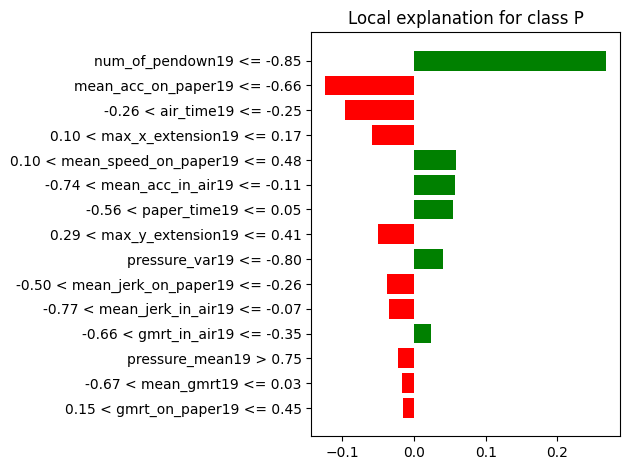


Calculando importancia global LIME...

Top-20 features por importancia global LIME:
   1. num_of_pendown19                          0.15212
   2. max_y_extension19                         0.15106
   3. air_time19                                0.11183
   4. mean_speed_on_paper19                     0.10264
   5. mean_acc_on_paper19                       0.09459
   6. mean_acc_in_air19                         0.07960
   7. paper_time19                              0.07178
   8. max_x_extension19                         0.05564
   9. pressure_mean19                           0.04855
  10. gmrt_on_paper19                           0.04333
  11. mean_gmrt19                               0.03852
  12. disp_index19                              0.03842
  13. gmrt_in_air19                             0.03763
  14. mean_jerk_in_air19                        0.03760
  15. pressure_var19                            0.03434
  16. mean_jerk_on_paper19                      0.03434
  17. total_time19 

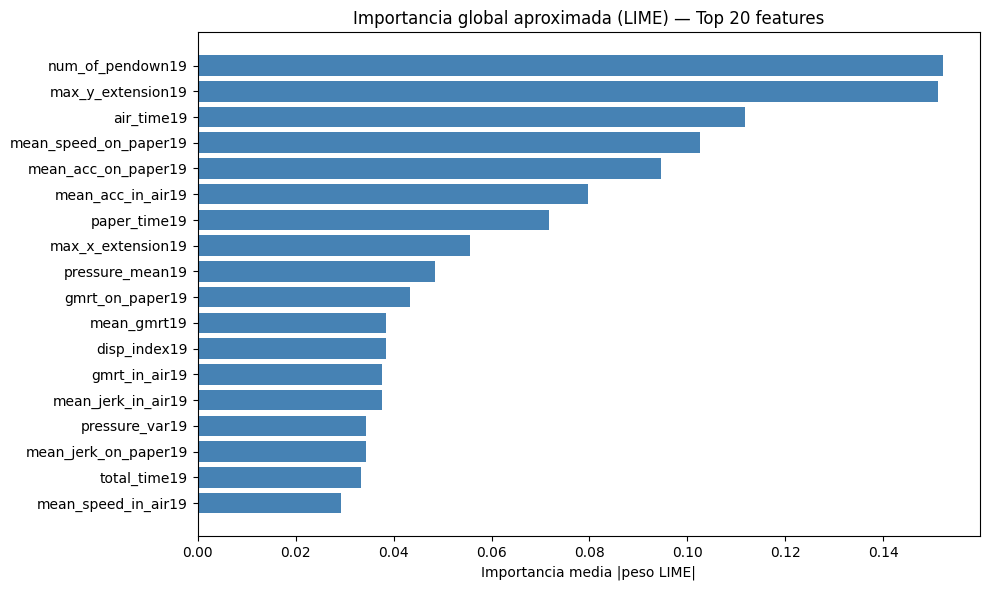

In [10]:
# ─────────────────────────────────────────
# LIME - EXPLICABILIDAD DEL MODELO RF
# ─────────────────────────────────────────

# Explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data = X_train_scaled,
    feature_names = X.columns.tolist(),
    class_names   = ["H", "P"],
    mode          = "classification",
    random_state  = 42
)

# ── Explicación individual (instancia 1) ──
INSTANCE_IDX = 1
instance = X_test_scaled[INSTANCE_IDX]

exp = explainer.explain_instance(
    data_row   = instance,
    predict_fn = tree_model.predict_proba, # best_tree o tree_model
    num_features = 15,
    num_samples  = 5000
)

print(f"\n--- LIME: instancia {INSTANCE_IDX} ---")
print(f"Clase real     : {Y_test[INSTANCE_IDX]}")
print(f"Clase predicha : {Y_pred_dt[INSTANCE_IDX]}") # Y_pred_opt Y_pred_dt
print(f"Probabilidades : H={tree_model.predict_proba([instance])[0][0]:.3f} | " # best
      f"P={tree_model.predict_proba([instance])[0][1]:.3f}")  # best
print("\nTop features (peso LIME):")
for feat, weight in exp.as_list():
    print(f"  {feat:45s}  {weight:+.4f}")

fig = exp.as_pyplot_figure()
fig.tight_layout()
plt.show()

# ── Importancia global aproximada ──
print("\nCalculando importancia global LIME...")

all_weights = {feat: [] for feat in X.columns}

for i in range(len(X_test_scaled)):
    exp_i = explainer.explain_instance(
        data_row     = X_test_scaled[i],
        predict_fn   = tree_model.predict_proba, # best
        num_features = 15,
        num_samples  = 1000
    )
    for feat, weight in exp_i.as_list():
        for col in X.columns:
            if col in feat:
                all_weights[col].append(abs(weight))
                break

global_importance = {
    feat: np.mean(weights) if weights else 0.0
    for feat, weights in all_weights.items()
}

top_global = sorted(global_importance.items(), key=lambda x: x[1], reverse=True)[:20]

print("\nTop-20 features por importancia global LIME:")
for rank, (feat, score) in enumerate(top_global, 1):
    print(f"  {rank:2d}. {feat:40s}  {score:.5f}")

feats, scores = zip(*top_global)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feats[::-1], scores[::-1], color="steelblue")
ax.set_xlabel("Importancia media |peso LIME|")
ax.set_title("Importancia global aproximada (LIME) — Top 20 features")
plt.tight_layout()
plt.show()

## RANDOM FOREST

In [11]:
# Modelo
rf_model = RandomForestClassifier(n_estimators=100, # 100 árboles
                                  random_state=42) # resultados reproducibles

# Se entrena el modelo
rf_model.fit(X_train_scaled, Y_train)

# Predicciones
Y_pred_rf = rf_model.predict(X_test_scaled)

# Resultados
print(" --- INFORME DE CLASIFICACIÓN: ---") # informe de clasificación
print(classification_report(Y_test, Y_pred_rf))

# Matriz de confusión
print(" --- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_rf))

# Sensibilidad y especificidad
tn_rf, fp_rf, fn_rf, tp_rf = confusion_matrix(Y_test, Y_pred_rf).ravel()

print(f"Sensibilidad: {tp_rf / (tp_rf + fn_rf):.2f}")
print(f"Especificidad: {tn_rf / (tn_rf + fp_rf):.2f}")

 --- INFORME DE CLASIFICACIÓN: ---
              precision    recall  f1-score   support

           0       0.72      0.76      0.74        17
           1       0.76      0.72      0.74        18

    accuracy                           0.74        35
   macro avg       0.74      0.74      0.74        35
weighted avg       0.74      0.74      0.74        35

 --- MATRIZ DE CONFUSIÓN ---
[[13  4]
 [ 5 13]]
Sensibilidad: 0.72
Especificidad: 0.76


**SHAP**

Shape shap_values_rf: (35, 18, 2)
Shape sv_rf: (35, 18)


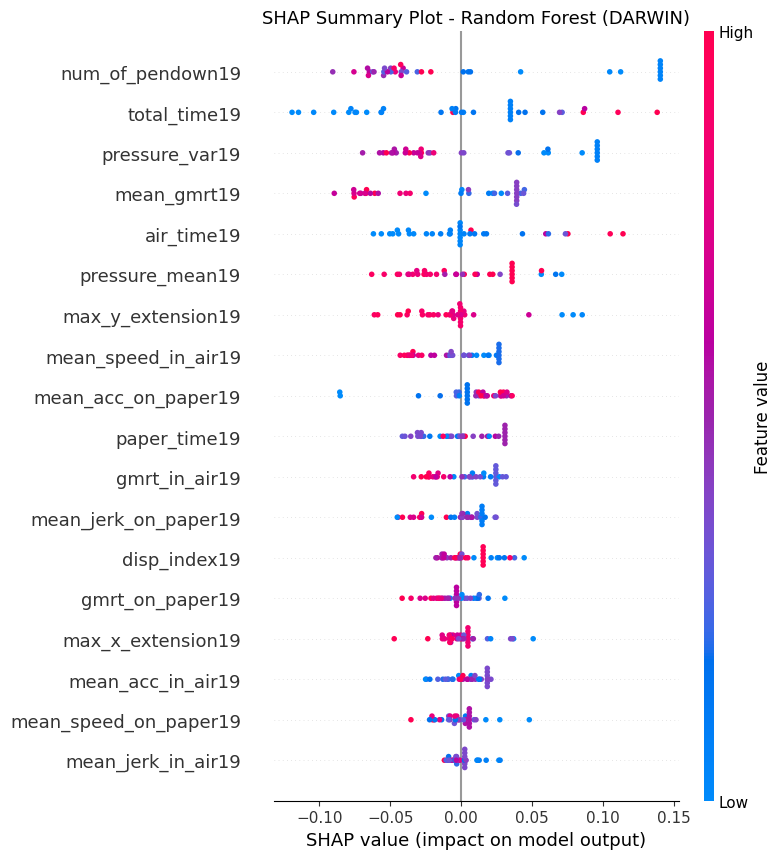

✔ Summary plot guardado.


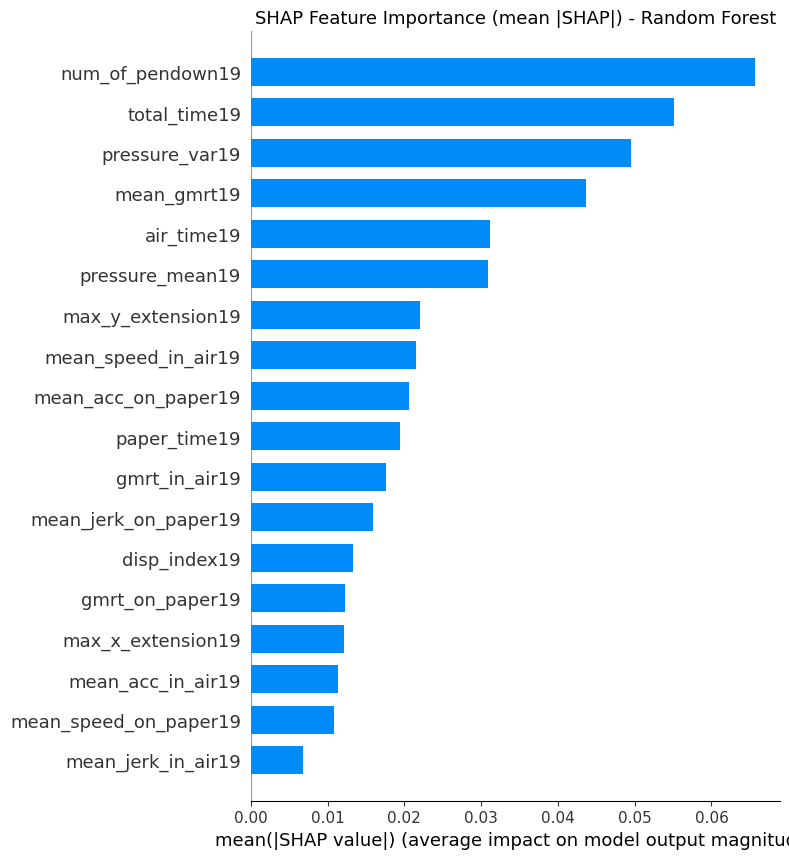

✔ Bar plot guardado.
expected_value_rf: [0.48964029 0.51035971]


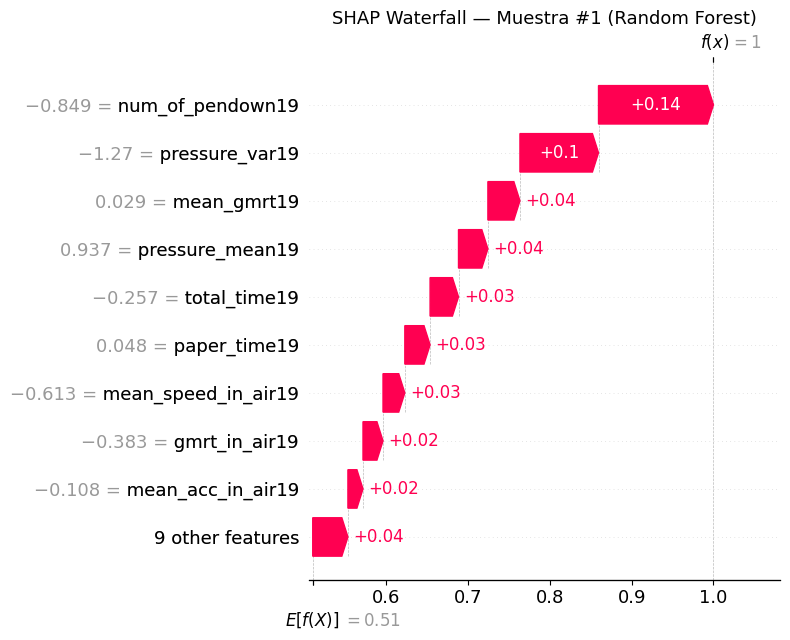

✔ Waterfall plot guardado.


<Figure size 640x480 with 0 Axes>

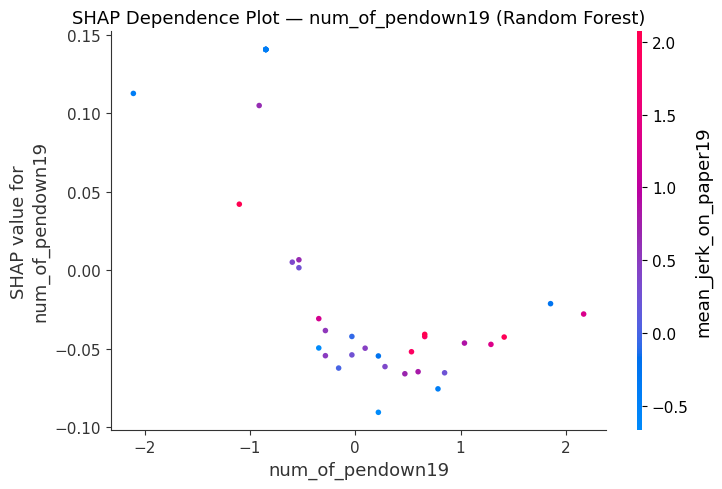

✔ Dependence plot guardado para: num_of_pendown19

=== TOP 10 FEATURES MÁS RELEVANTES (SHAP - Random Forest) ===
            Feature  Mean |SHAP|
   num_of_pendown19     0.065638
       total_time19     0.055058
     pressure_var19     0.049565
        mean_gmrt19     0.043690
         air_time19     0.031213
    pressure_mean19     0.030946
  max_y_extension19     0.022091
mean_speed_in_air19     0.021488
mean_acc_on_paper19     0.020597
       paper_time19     0.019489


In [12]:
# ============================================================
# ANÁLISIS SHAP PARA RANDOM FOREST
# ============================================================

# Explainer
explainer_rf = shap.TreeExplainer(rf_model) # rf_model o best_rf

# SHAP values
shap_values_rf = explainer_rf.shap_values(X_test_scaled)

# Verificar estructura (por consistencia con tu entorno)
print("Shape shap_values_rf:", np.array(shap_values_rf).shape)

# Extraer clase positiva (Parkinson) — estructura (n_muestras, n_features, n_clases)
sv_rf = np.array(shap_values_rf)[:, :, 1]  # shape (35, 450)
print("Shape sv_rf:", sv_rf.shape)

# ============================================================
# Summary Plot (Beeswarm)
# ============================================================
plt.figure()
shap.summary_plot(
    sv_rf,
    X_test_scaled,
    feature_names=X.columns.tolist(),
    show=False
)
plt.title("SHAP Summary Plot - Random Forest (DARWIN)", fontsize=13)
plt.tight_layout()
plt.savefig("shap_rf_summary_beeswarm.png", dpi=150, bbox_inches='tight')
plt.show()
print("✔ Summary plot guardado.")

# ============================================================
# Bar Plot
# ============================================================
plt.figure()
shap.summary_plot(
    sv_rf,
    X_test_scaled,
    feature_names=X.columns.tolist(),
    plot_type="bar",
    show=False
)
plt.title("SHAP Feature Importance (mean |SHAP|) - Random Forest", fontsize=13)
plt.tight_layout()
plt.savefig("shap_rf_bar_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print("✔ Bar plot guardado.")

# ============================================================
# Waterfall Plot
# ============================================================
sample_idx = 1

# Verificar expected_value
print("expected_value_rf:", explainer_rf.expected_value)

explanation_rf = shap.Explanation(
    values=sv_rf[sample_idx],
    base_values=explainer_rf.expected_value[1],  # si es escalar → quitar [1]
    data=X_test_scaled[sample_idx],
    feature_names=X.columns.tolist()
)

plt.figure()
shap.plots.waterfall(explanation_rf, show=False)
plt.title(f"SHAP Waterfall — Muestra #{sample_idx} (Random Forest)", fontsize=13)
plt.tight_layout()
plt.savefig("shap_rf_waterfall.png", dpi=150, bbox_inches='tight')
plt.show()
print("✔ Waterfall plot guardado.")

# ============================================================
# Dependence Plot
# ============================================================
mean_abs_shap_rf = np.abs(sv_rf).mean(axis=0)
top_feature_idx_rf = np.argmax(mean_abs_shap_rf)
top_feature_name_rf = X.columns[top_feature_idx_rf]

plt.figure()
shap.dependence_plot(
    top_feature_idx_rf,
    sv_rf,
    X_test_scaled,
    feature_names=X.columns.tolist(),
    show=False
)
plt.title(f"SHAP Dependence Plot — {top_feature_name_rf} (Random Forest)", fontsize=13)
plt.tight_layout()
plt.savefig("shap_rf_dependence.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✔ Dependence plot guardado para: {top_feature_name_rf}")

# ============================================================
# RESUMEN NUMÉRICO: Top 10 features
# ============================================================
feature_importance_rf_df = pd.DataFrame({
    'Feature': X.columns,
    'Mean |SHAP|': mean_abs_shap_rf
}).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)

print("\n=== TOP 10 FEATURES MÁS RELEVANTES (SHAP - Random Forest) ===")
print(feature_importance_rf_df.head(10).to_string(index=False))

**LIME**


--- LIME: instancia 1 ---
Clase real     : 1
Clase predicha : 1
Probabilidades : H=0.000 | P=1.000
  num_of_pendown19 <= -0.85                      +0.1383
  pressure_var19 <= -0.80                        +0.0794
  mean_acc_on_paper19 <= -0.66                   -0.0436
  0.29 < max_y_extension19 <= 0.41               -0.0325
  -0.67 < mean_gmrt19 <= 0.03                    +0.0275
  pressure_mean19 > 0.75                         +0.0238
  0.15 < gmrt_on_paper19 <= 0.45                 -0.0227
  -0.26 < air_time19 <= -0.25                    -0.0175
  -0.66 < gmrt_in_air19 <= -0.35                 +0.0164
  -0.74 < mean_acc_in_air19 <= -0.11             -0.0156
  0.10 < max_x_extension19 <= 0.17               -0.0115
  -0.50 < mean_jerk_on_paper19 <= -0.26          +0.0107
  -0.65 < mean_speed_in_air19 <= -0.30           +0.0078
  -0.26 < total_time19 <= -0.25                  -0.0066
  0.10 < mean_speed_on_paper19 <= 0.48           -0.0049


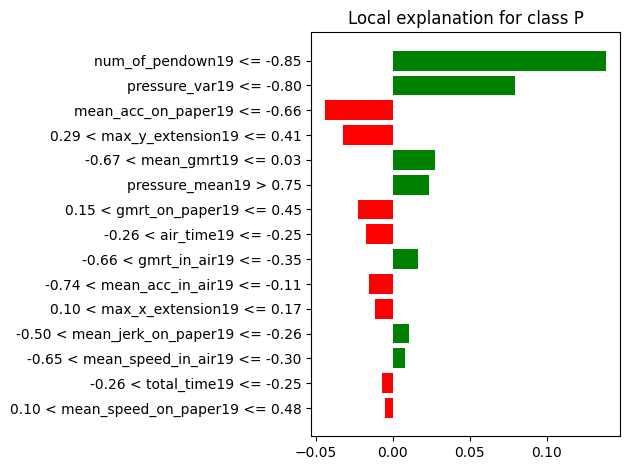


Calculando importancia global LIME...

Top-20 features por importancia global LIME:
   1. num_of_pendown19                          0.07399
   2. total_time19                              0.05621
   3. pressure_var19                            0.05456
   4. air_time19                                0.04137
   5. max_y_extension19                         0.04022
   6. mean_gmrt19                               0.03387
   7. mean_acc_on_paper19                       0.03021
   8. pressure_mean19                           0.02948
   9. gmrt_on_paper19                           0.02395
  10. mean_speed_in_air19                       0.01982
  11. mean_speed_on_paper19                     0.01942
  12. disp_index19                              0.01855
  13. max_x_extension19                         0.01648
  14. mean_jerk_on_paper19                      0.01599
  15. gmrt_in_air19                             0.01583
  16. mean_acc_in_air19                         0.01578
  17. paper_time19 

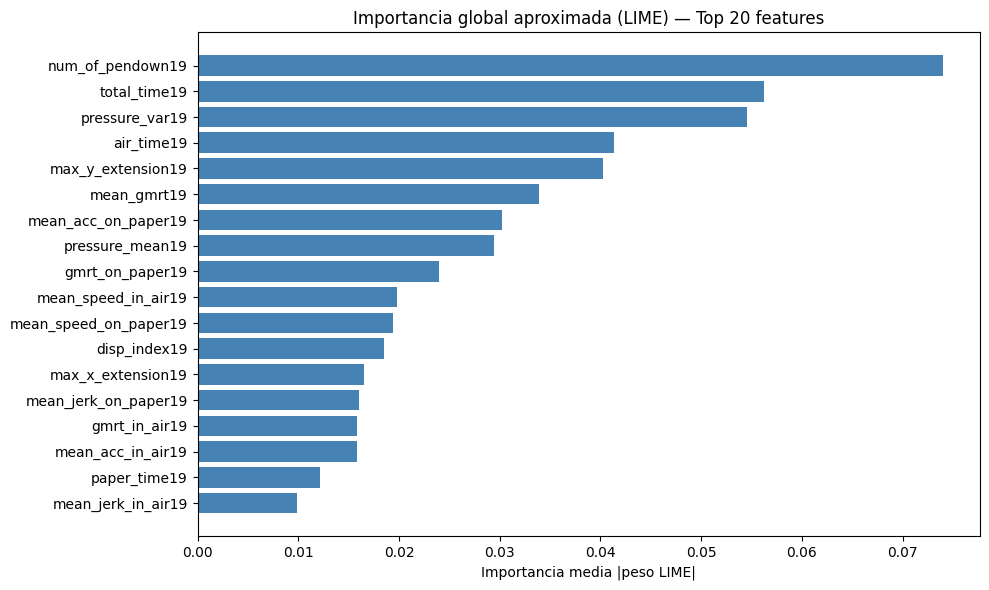

In [13]:
# ─────────────────────────────────────────
# LIME - EXPLICABILIDAD DEL MODELO RF
# ─────────────────────────────────────────

# Explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data = X_train_scaled,
    feature_names = X.columns.tolist(),
    class_names   = ["H", "P"],
    mode          = "classification",
    random_state  = 42
)

# ── Explicación individual (instancia 1) ──
INSTANCE_IDX = 1
instance = X_test_scaled[INSTANCE_IDX]

exp = explainer.explain_instance(
    data_row   = instance,
    predict_fn = rf_model.predict_proba, # rf_model best_rf
    num_features = 15,
    num_samples  = 5000
)

print(f"\n--- LIME: instancia {INSTANCE_IDX} ---")
print(f"Clase real     : {Y_test[INSTANCE_IDX]}")
print(f"Clase predicha : {Y_pred_rf[INSTANCE_IDX]}") # Y_pred_rf Y_pred_rf2
print(f"Probabilidades : H={rf_model.predict_proba([instance])[0][0]:.3f} | " # rf_model best_rf
      f"P={rf_model.predict_proba([instance])[0][1]:.3f}") # best
for feat, weight in exp.as_list():
    print(f"  {feat:45s}  {weight:+.4f}")

fig = exp.as_pyplot_figure()
fig.tight_layout()
plt.show()

# ── Importancia global aproximada ──
print("\nCalculando importancia global LIME...")

all_weights = {feat: [] for feat in X.columns}

for i in range(len(X_test_scaled)):
    exp_i = explainer.explain_instance(
        data_row     = X_test_scaled[i],
        predict_fn   = rf_model.predict_proba, # rf_model
        num_features = 15,
        num_samples  = 1000
    )
    for feat, weight in exp_i.as_list():
        for col in X.columns:
            if col in feat:
                all_weights[col].append(abs(weight))
                break

global_importance = {
    feat: np.mean(weights) if weights else 0.0
    for feat, weights in all_weights.items()
}

top_global = sorted(global_importance.items(), key=lambda x: x[1], reverse=True)[:20]

print("\nTop-20 features por importancia global LIME:")
for rank, (feat, score) in enumerate(top_global, 1):
    print(f"  {rank:2d}. {feat:40s}  {score:.5f}")

feats, scores = zip(*top_global)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feats[::-1], scores[::-1], color="steelblue")
ax.set_xlabel("Importancia media |peso LIME|")
ax.set_title("Importancia global aproximada (LIME) — Top 20 features")
plt.tight_layout()
plt.show()

## XGBOOST

In [14]:
# Modelo
modelo_xgb = xgb.XGBClassifier(
    n_estimators = 100, # nº árboles
    learning_rate = 0.1, # paso de aprendizaje
    max_depth = 3, # profundidad árboles
    use_label_encoder = False,
    eval_metrics = 'logloss',
    base_score=0.5
)

# Se entrena
modelo_xgb.fit(X_train_scaled, Y_train)

# Predicciones
Y_pred_xgb = modelo_xgb.predict(X_test_scaled)

# Resultados
print(" --- INFORME DE CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred_xgb))

print("--- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_xgb))

# TP; TN; FP; FN
tn_xgb, fp_xgb, fn_xgb, tp_xgb = confusion_matrix(Y_test, Y_pred_xgb).ravel()

print(f"Sensibilidad: {tp_xgb / (tp_xgb + fn_xgb):.2f}")
print(f"Especificidad: {tn_xgb / (tn_xgb + fp_xgb):.2f}")

/opt/miniconda3/envs/tfm_env/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [21:00:11] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "eval_metrics", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


 --- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.78      0.82      0.80        17
           1       0.82      0.78      0.80        18

    accuracy                           0.80        35
   macro avg       0.80      0.80      0.80        35
weighted avg       0.80      0.80      0.80        35

--- MATRIZ DE CONFUSIÓN ---
[[14  3]
 [ 4 14]]
Sensibilidad: 0.78
Especificidad: 0.82


**SHAP**

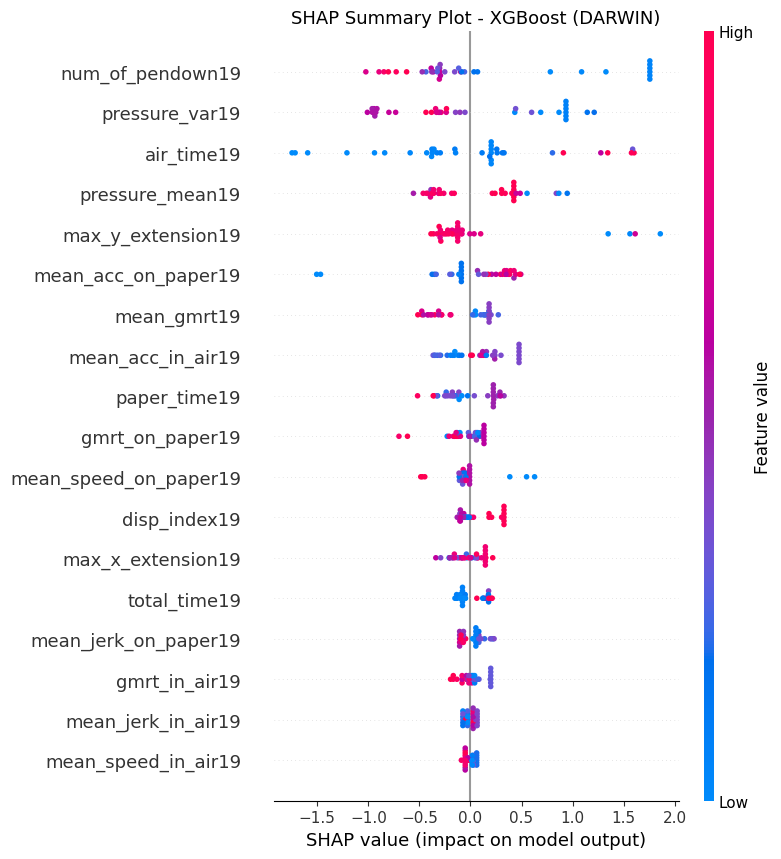

✔ Summary plot guardado.


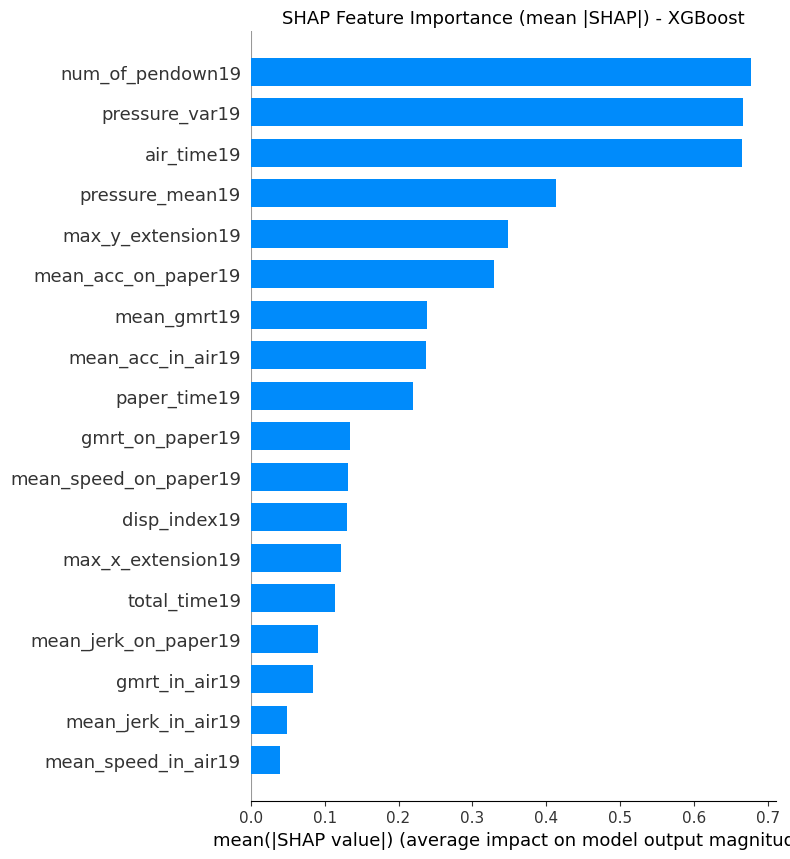

✔ Bar plot guardado.


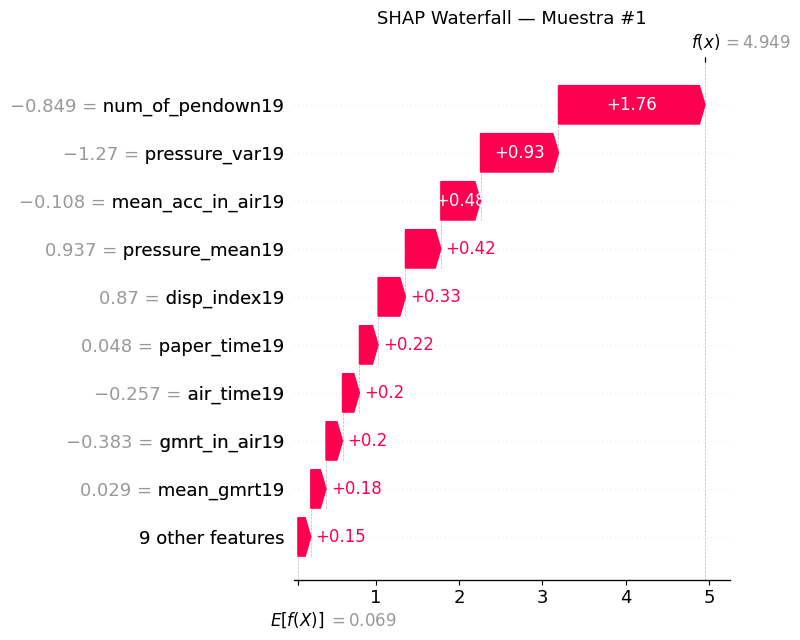

✔ Waterfall plot guardado.


<Figure size 640x480 with 0 Axes>

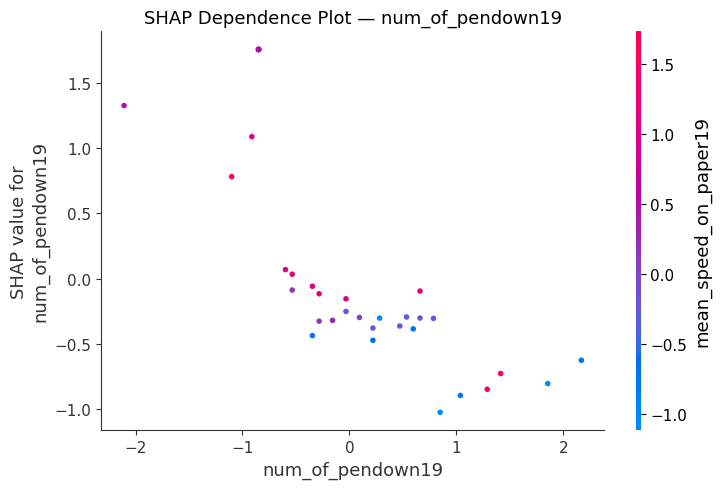

✔ Dependence plot guardado para: num_of_pendown19

=== TOP 10 FEATURES MÁS RELEVANTES (SHAP) ===
            Feature  Mean |SHAP|
   num_of_pendown19     0.677467
     pressure_var19     0.665711
         air_time19     0.664495
    pressure_mean19     0.413087
  max_y_extension19     0.348718
mean_acc_on_paper19     0.329305
        mean_gmrt19     0.239113
  mean_acc_in_air19     0.237748
       paper_time19     0.220132
    gmrt_on_paper19     0.134129


In [15]:
# ============================================================
# ANÁLISIS SHAP PARA XGBOOST
# ============================================================

# Explainer SHAP (TreeExplainer es el óptimo para XGBoost)
explainer = shap.TreeExplainer(modelo_xgb) # 2

# Calcular los SHAP values sobre el test set
shap_values = explainer.shap_values(X_test_scaled)

# ============================================================
# Summary Plot (Beeswarm)
# ============================================================
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X.columns.tolist(),
    show=False
)
plt.title("SHAP Summary Plot - XGBoost (DARWIN)", fontsize=13)
plt.tight_layout()
plt.savefig("shap_summary_beeswarm.png", dpi=150, bbox_inches='tight')
plt.show()
print("✔ Summary plot guardado.")

# ============================================================
# Bar Plot 
# ============================================================
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X.columns.tolist(),
    plot_type="bar",
    show=False
)
plt.title("SHAP Feature Importance (mean |SHAP|) - XGBoost", fontsize=13)
plt.tight_layout()
plt.savefig("shap_bar_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print("✔ Bar plot guardado.")

# ============================================================
# Waterfall Plot
# ============================================================
sample_idx = 1

explanation = shap.Explanation(
    values=shap_values[sample_idx],
    base_values=explainer.expected_value,
    data=X_test_scaled[sample_idx] if hasattr(X_test_scaled, '__array__') else X_test_scaled.iloc[sample_idx].values,
    feature_names=X.columns.tolist()
)

plt.figure()
shap.plots.waterfall(explanation, show=False)
plt.title(f"SHAP Waterfall — Muestra #{sample_idx}", fontsize=13)
plt.tight_layout()
plt.savefig("shap_waterfall.png", dpi=150, bbox_inches='tight')
plt.show()
print("✔ Waterfall plot guardado.")

# ============================================================
# Dependence Plot 
# ============================================================
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_feature_idx = np.argmax(mean_abs_shap)
top_feature_name = X.columns[top_feature_idx]

plt.figure()
shap.dependence_plot(
    top_feature_idx,
    shap_values,
    X_test_scaled,
    feature_names=X.columns.tolist(),
    show=False
)
plt.title(f"SHAP Dependence Plot — {top_feature_name}", fontsize=13)
plt.tight_layout()
plt.savefig("shap_dependence.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✔ Dependence plot guardado para: {top_feature_name}")

# ============================================================
# RESUMEN NUMÉRICO: Top 10 features por |SHAP| medio
# ============================================================
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Mean |SHAP|': mean_abs_shap
}).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)

print("\n=== TOP 10 FEATURES MÁS RELEVANTES (SHAP) ===")
print(feature_importance_df.head(10).to_string(index=False))

**LIME**


--- LIME XGBoost: instancia 1 ---
Clase real     : 1
Clase predicha : 1
Probabilidades : H=0.007 | P=0.993

Top features (peso LIME):
  num_of_pendown19 <= -0.85                      +0.2442
  pressure_var19 <= -0.80                        +0.1668
  mean_acc_on_paper19 <= -0.66                   -0.1448
  0.29 < max_y_extension19 <= 0.41               -0.0996
  -0.74 < mean_acc_in_air19 <= -0.11             -0.0649
  -0.26 < air_time19 <= -0.25                    -0.0520
  -0.67 < mean_gmrt19 <= 0.03                    +0.0444
  pressure_mean19 > 0.75                         +0.0433
  -0.66 < gmrt_in_air19 <= -0.35                 +0.0299
  0.10 < mean_speed_on_paper19 <= 0.48           -0.0246
  -0.56 < paper_time19 <= 0.05                   +0.0239
  -0.26 < total_time19 <= -0.25                  -0.0199
  0.11 < disp_index19 <= 0.87                    +0.0163
  0.15 < gmrt_on_paper19 <= 0.45                 +0.0125
  0.10 < max_x_extension19 <= 0.17               +0.0050


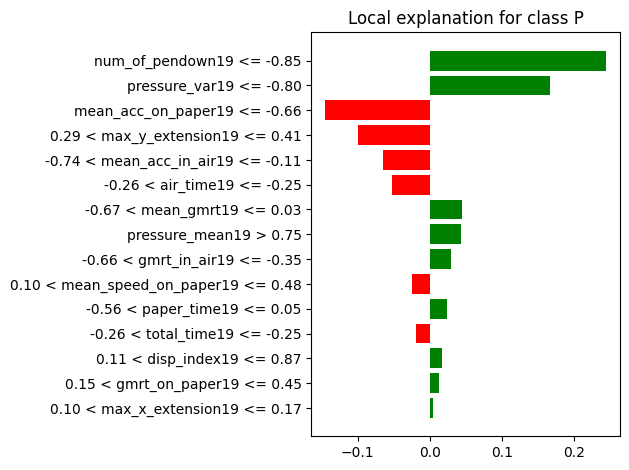


Calculando importancia global LIME (XGBoost)...

Top-20 features por importancia global LIME (XGBoost):
   1. air_time19                                0.17084
   2. num_of_pendown19                          0.13929
   3. max_y_extension19                         0.12845
   4. pressure_var19                            0.10282
   5. mean_acc_on_paper19                       0.09115
   6. pressure_mean19                           0.05912
   7. mean_acc_in_air19                         0.05284
   8. mean_gmrt19                               0.04706
   9. mean_speed_on_paper19                     0.04111
  10. gmrt_on_paper19                           0.03560
  11. total_time19                              0.02925
  12. paper_time19                              0.02900
  13. gmrt_in_air19                             0.02614
  14. disp_index19                              0.02564
  15. mean_jerk_on_paper19                      0.02402
  16. mean_jerk_in_air19                        0.02257

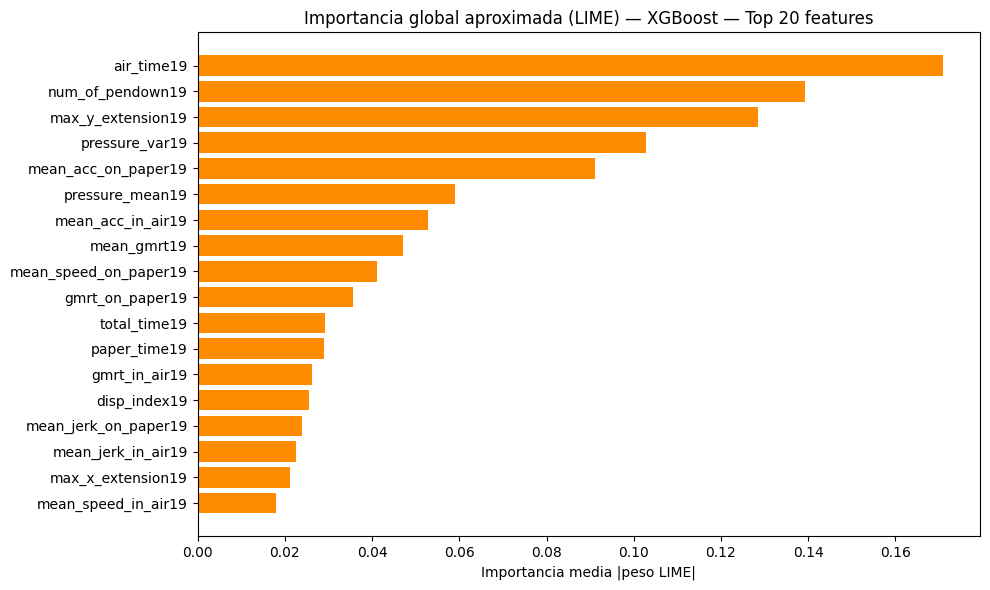

In [16]:
# ─────────────────────────────────────────
# LIME - EXPLICABILIDAD DEL MODELO XGBoost
# ─────────────────────────────────────────

# Explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data = X_train_scaled,
    feature_names = X.columns.tolist(),
    class_names   = ["H", "P"],
    mode          = "classification",
    random_state  = 42
)

# ── Explicación individual (instancia 1) ──
INSTANCE_IDX = 1
instance = X_test_scaled[INSTANCE_IDX]

exp = explainer.explain_instance(
    data_row   = instance,
    predict_fn = modelo_xgb.predict_proba, # modelo_xgb modelo_xgb2
    num_features = 15,
    num_samples  = 5000
)

print(f"\n--- LIME XGBoost: instancia {INSTANCE_IDX} ---")
print(f"Clase real     : {Y_test[INSTANCE_IDX]}")
print(f"Clase predicha : {Y_pred_xgb[INSTANCE_IDX]}") # Y_pred_xgb Y_pred_xgb2
print(f"Probabilidades : H={modelo_xgb.predict_proba([instance])[0][0]:.3f} | " # 2
      f"P={modelo_xgb.predict_proba([instance])[0][1]:.3f}") # 2
print("\nTop features (peso LIME):")
for feat, weight in exp.as_list():
    print(f"  {feat:45s}  {weight:+.4f}")

fig = exp.as_pyplot_figure()
fig.tight_layout()
plt.show()

# ── Importancia global aproximada ──
print("\nCalculando importancia global LIME (XGBoost)...")

all_weights = {feat: [] for feat in X.columns}

for i in range(len(X_test_scaled)):
    exp_i = explainer.explain_instance(
        data_row     = X_test_scaled[i],
        predict_fn   = modelo_xgb.predict_proba, # 2
        num_features = 15,
        num_samples  = 1000
    )
    for feat, weight in exp_i.as_list():
        for col in X.columns:
            if col in feat:
                all_weights[col].append(abs(weight))
                break

global_importance = {
    feat: np.mean(weights) if weights else 0.0
    for feat, weights in all_weights.items()
}

top_global = sorted(global_importance.items(), key=lambda x: x[1], reverse=True)[:20]

print("\nTop-20 features por importancia global LIME (XGBoost):")
for rank, (feat, score) in enumerate(top_global, 1):
    print(f"  {rank:2d}. {feat:40s}  {score:.5f}")

feats, scores = zip(*top_global)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feats[::-1], scores[::-1], color="darkorange")
ax.set_xlabel("Importancia media |peso LIME|")
ax.set_title("Importancia global aproximada (LIME) — XGBoost — Top 20 features")
plt.tight_layout()
plt.show()

## Gaussian Naive Bayes

In [17]:
# Modelo
gnb = GaussianNB()

# Se entrena el modelo
gnb.fit(X_train_scaled, Y_train)

# Se realizan las predicciones
Y_pred_gnb = gnb.predict(X_test_scaled)

# Resultados
print("--- INFORME DE CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred_gnb))

print(" --- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_gnb))

# Sensibilidad y especificidad
tn_gnb, fp_gnb, fn_gnb, tp_gnb = confusion_matrix(Y_test, Y_pred_gnb).ravel()

print(f"Sensibilidad: {tp_gnb / (tp_gnb + fn_gnb):.2f}")
print(f"Especificidad: {tn_gnb / (tn_gnb + fp_gnb):.2f}")

--- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.86      0.35      0.50        17
           1       0.61      0.94      0.74        18

    accuracy                           0.66        35
   macro avg       0.73      0.65      0.62        35
weighted avg       0.73      0.66      0.62        35

 --- MATRIZ DE CONFUSIÓN ---
[[ 6 11]
 [ 1 17]]
Sensibilidad: 0.94
Especificidad: 0.35


**SHAP**

100%|██████████| 35/35 [00:10<00:00,  3.43it/s]


Shape shap_values_gnb: (35, 18, 2)
Shape sv_gnb: (35, 18)
expected_value shape: (2,)
expected_value: [0.18062854 0.81937146]
base_val usado: 0.8193714604028716


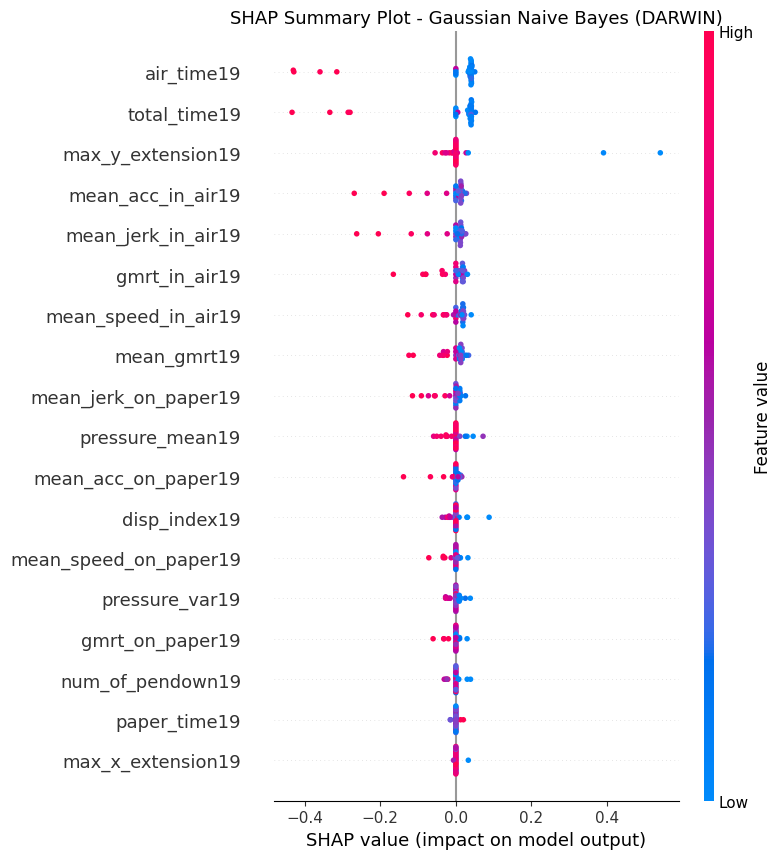

✔ Summary plot guardado.


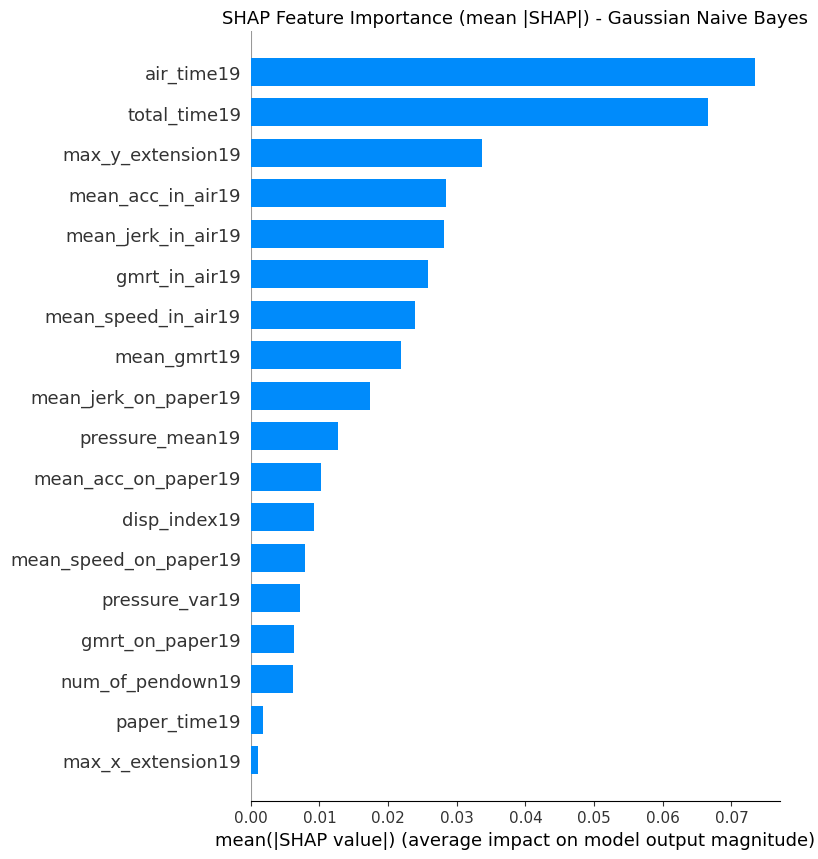

✔ Bar plot guardado.


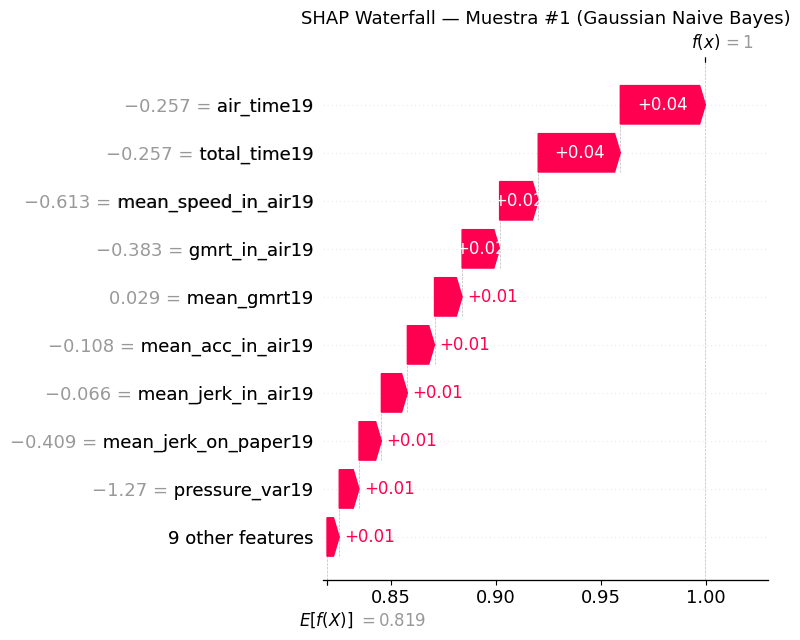

✔ Waterfall plot guardado.


<Figure size 640x480 with 0 Axes>

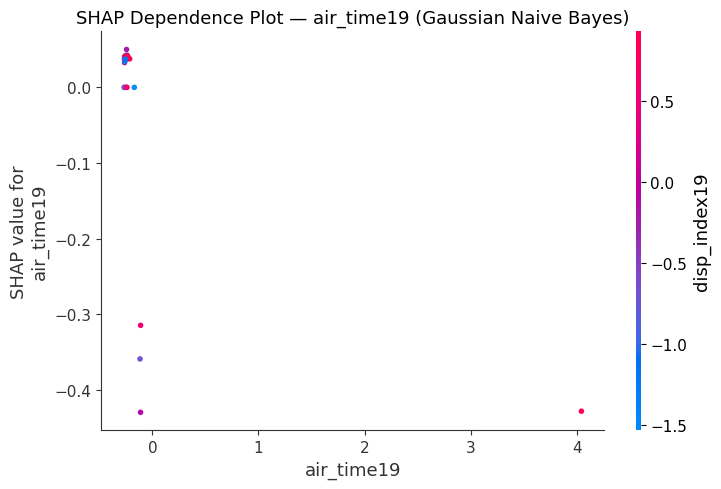

✔ Dependence plot guardado para: air_time19

=== TOP 10 FEATURES MÁS RELEVANTES (SHAP - Gaussian Naive Bayes) ===
             Feature  Mean |SHAP|
          air_time19     0.073393
        total_time19     0.066560
   max_y_extension19     0.033730
   mean_acc_in_air19     0.028396
  mean_jerk_in_air19     0.028200
       gmrt_in_air19     0.025754
 mean_speed_in_air19     0.023876
         mean_gmrt19     0.021915
mean_jerk_on_paper19     0.017394
     pressure_mean19     0.012736


In [18]:
# ============================================================
# ANÁLISIS SHAP PARA GAUSSIAN NAIVE BAYES
# ============================================================

background = shap.sample(X_train_scaled, 100)  # 100 muestras como background

# Explainer 
explainer_gnb = shap.KernelExplainer(gnb.predict_proba, background)

# SHAP values
shap_values_gnb = explainer_gnb.shap_values(X_test_scaled, nsamples="auto")

# Se verifica la estructura
print("Shape shap_values_gnb:", np.array(shap_values_gnb).shape)


# Se extrae la clase positiva (P = 1)
sv_gnb = shap_values_gnb[:, :, 1]  # shape (35, 450)
print("Shape sv_gnb:", sv_gnb.shape)

# Se convierte X_test_scaled a DataFrame para que los plots usen nombres de features
X_test_df = pd.DataFrame(X_test_scaled, columns=X.columns.tolist())

# expected_value para clase positiva
ev = np.array(explainer_gnb.expected_value)
print("expected_value shape:", ev.shape)
print("expected_value:", ev)

# Si ev tiene shape (n_muestras, 2) se usa la media; si es (2,) usamos índice 1
if ev.ndim == 2:
    base_val = ev[:, 1].mean()
elif ev.ndim == 1:
    base_val = ev[1]
else:
    base_val = float(ev)

print("base_val usado:", base_val)

# ============================================================
# Summary Plot (Beeswarm)
# ============================================================
plt.figure()
shap.summary_plot(
    sv_gnb,
    X_test_df,
    show=False
)
plt.title("SHAP Summary Plot - Gaussian Naive Bayes (DARWIN)", fontsize=13)
plt.tight_layout()
plt.savefig("shap_gnb_summary_beeswarm.png", dpi=150, bbox_inches='tight')
plt.show()
print("✔ Summary plot guardado.")

# ============================================================
# Bar Plot — Importancia media global
# ============================================================
plt.figure()
shap.summary_plot(
    sv_gnb,
    X_test_df,
    plot_type="bar",
    show=False
)
plt.title("SHAP Feature Importance (mean |SHAP|) - Gaussian Naive Bayes", fontsize=13)
plt.tight_layout()
plt.savefig("shap_gnb_bar_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print("✔ Bar plot guardado.")

# ============================================================
# Waterfall Plot — Explicación individual
# ============================================================
sample_idx = 1

explanation_gnb = shap.Explanation(
    values=sv_gnb[sample_idx],
    base_values=base_val,
    data=X_test_df.iloc[sample_idx],
    feature_names=X.columns.tolist()
)
plt.figure()
shap.plots.waterfall(explanation_gnb, show=False)
plt.title(f"SHAP Waterfall — Muestra #{sample_idx} (Gaussian Naive Bayes)", fontsize=13)
plt.tight_layout()
plt.savefig("shap_gnb_waterfall.png", dpi=150, bbox_inches='tight')
plt.show()
print("✔ Waterfall plot guardado.")

# ============================================================
# Dependence Plot — Feature más importante
# ============================================================
mean_abs_shap_gnb = np.abs(sv_gnb).mean(axis=0)
top_feature_idx_gnb = np.argmax(mean_abs_shap_gnb)
top_feature_name_gnb = X.columns[top_feature_idx_gnb]

plt.figure()
shap.dependence_plot(
    top_feature_idx_gnb,
    sv_gnb,
    X_test_df,
    show=False
)
plt.title(f"SHAP Dependence Plot — {top_feature_name_gnb} (Gaussian Naive Bayes)", fontsize=13)
plt.tight_layout()
plt.savefig("shap_gnb_dependence.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✔ Dependence plot guardado para: {top_feature_name_gnb}")

# ============================================================
# RESUMEN NUMÉRICO: Top 10 features
# ============================================================
feature_importance_gnb_df = pd.DataFrame({
    'Feature': X.columns,
    'Mean |SHAP|': mean_abs_shap_gnb
}).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)

print("\n=== TOP 10 FEATURES MÁS RELEVANTES (SHAP - Gaussian Naive Bayes) ===")
print(feature_importance_gnb_df.head(10).to_string(index=False))

**LIME**


--- LIME: instancia 1 (Gaussian Naive Bayes) ---
Clase real     : 1
Clase predicha : 1
Probabilidades : H=0.000 | P=1.000

Top features (peso LIME):
  -0.26 < air_time19 <= -0.25                    +0.2450
  -0.26 < total_time19 <= -0.25                  +0.2426
  0.29 < max_y_extension19 <= 0.41               -0.0225
  0.15 < gmrt_on_paper19 <= 0.45                 +0.0209
  num_of_pendown19 <= -0.85                      +0.0193
  -0.50 < mean_jerk_on_paper19 <= -0.26          +0.0178
  -0.67 < mean_gmrt19 <= 0.03                    -0.0175
  0.11 < disp_index19 <= 0.87                    +0.0167
  mean_acc_on_paper19 <= -0.66                   +0.0151
  0.10 < max_x_extension19 <= 0.17               +0.0143
  pressure_mean19 > 0.75                         -0.0092
  -0.56 < paper_time19 <= 0.05                   -0.0087
  -0.65 < mean_speed_in_air19 <= -0.30           +0.0062
  -0.77 < mean_jerk_in_air19 <= -0.07            +0.0042
  pressure_var19 <= -0.80                        +0.

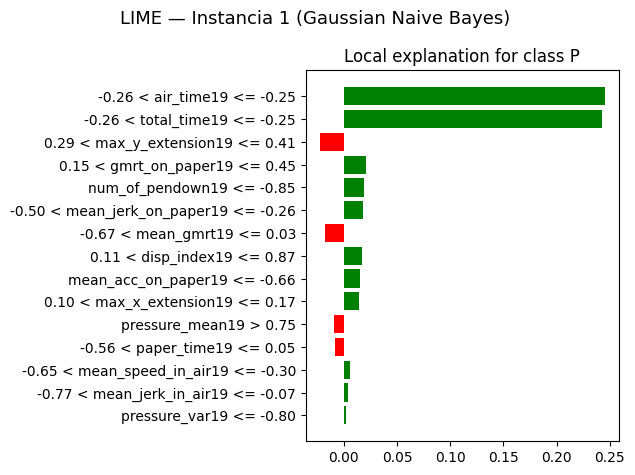


Calculando importancia global LIME (GNB)...

Top-20 features por importancia global LIME (Gaussian Naive Bayes):
   1. air_time19                                0.35039
   2. total_time19                              0.33319
   3. pressure_mean19                           0.03797
   4. mean_gmrt19                               0.03358
   5. max_x_extension19                         0.03338
   6. gmrt_in_air19                             0.03314
   7. mean_acc_in_air19                         0.03229
   8. mean_speed_in_air19                       0.03155
   9. mean_acc_on_paper19                       0.03128
  10. mean_jerk_in_air19                        0.03121
  11. gmrt_on_paper19                           0.03120
  12. mean_jerk_on_paper19                      0.02888
  13. disp_index19                              0.02885
  14. num_of_pendown19                          0.02856
  15. pressure_var19                            0.02841
  16. mean_speed_on_paper19                   

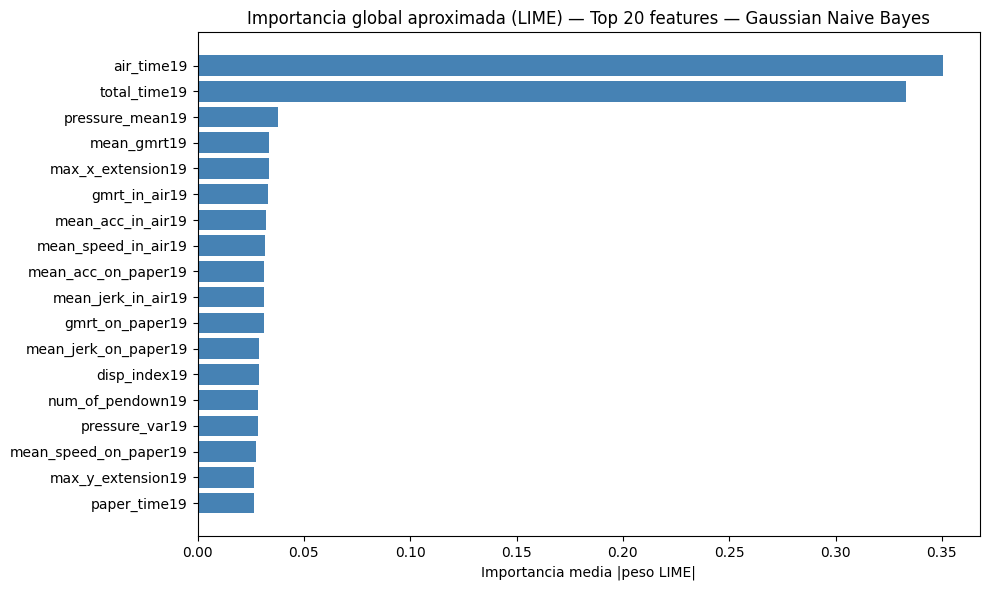

In [19]:
# ─────────────────────────────────────────
# LIME - EXPLICABILIDAD DEL MODELO GNB
# ─────────────────────────────────────────

# Explainer
explainer_lime_gnb = lime.lime_tabular.LimeTabularExplainer(
    training_data = X_train_scaled,
    feature_names = X.columns.tolist(),
    class_names   = ["H", "P"],
    mode          = "classification",
    random_state  = 42
)

# ── Explicación individual (instancia 1) ──
INSTANCE_IDX = 1
instance = X_test_scaled[INSTANCE_IDX]

exp_gnb = explainer_lime_gnb.explain_instance(
    data_row     = instance,
    predict_fn   = gnb.predict_proba,
    num_features = 15,
    num_samples  = 5000
)

print(f"\n--- LIME: instancia {INSTANCE_IDX} (Gaussian Naive Bayes) ---")
print(f"Clase real     : {Y_test[INSTANCE_IDX]}")
print(f"Clase predicha : {gnb.predict([instance])[0]}")
print(f"Probabilidades : H={gnb.predict_proba([instance])[0][0]:.3f} | "
      f"P={gnb.predict_proba([instance])[0][1]:.3f}")

print("\nTop features (peso LIME):")
for feat, weight in exp_gnb.as_list():
    print(f"  {feat:45s}  {weight:+.4f}")

fig = exp_gnb.as_pyplot_figure()
fig.suptitle(f"LIME — Instancia {INSTANCE_IDX} (Gaussian Naive Bayes)", fontsize=13)
fig.tight_layout()
plt.savefig("lime_gnb_instance.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Importancia global aproximada ──
print("\nCalculando importancia global LIME (GNB)...")

all_weights_gnb = {feat: [] for feat in X.columns}

for i in range(len(X_test_scaled)):
    exp_i = explainer_lime_gnb.explain_instance(
        data_row     = X_test_scaled[i],
        predict_fn   = gnb.predict_proba,
        num_features = 15,
        num_samples  = 1000
    )
    for feat, weight in exp_i.as_list():
        for col in X.columns:
            if col in feat:
                all_weights_gnb[col].append(abs(weight))
                break

global_importance_gnb = {
    feat: np.mean(weights) if weights else 0.0
    for feat, weights in all_weights_gnb.items()
}

top_global_gnb = sorted(global_importance_gnb.items(), key=lambda x: x[1], reverse=True)[:20]

print("\nTop-20 features por importancia global LIME (Gaussian Naive Bayes):")
for rank, (feat, score) in enumerate(top_global_gnb, 1):
    print(f"  {rank:2d}. {feat:40s}  {score:.5f}")

feats_gnb, scores_gnb = zip(*top_global_gnb)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feats_gnb[::-1], scores_gnb[::-1], color="steelblue")
ax.set_xlabel("Importancia media |peso LIME|")
ax.set_title("Importancia global aproximada (LIME) — Top 20 features — Gaussian Naive Bayes")
plt.tight_layout()
plt.savefig("lime_gnb_global_importance.png", dpi=150, bbox_inches='tight')
plt.show()

**RESUMEN**

In [20]:
# ============================================================
# TABLA RESUMEN SHAP — TODAS LAS VARIABLES, TOP 10 DESTACADO
# ============================================================

full_dt  = pd.DataFrame({'Feature': X.columns, 'Mean |SHAP| DT':  np.abs(sv).mean(axis=0)})
full_rf  = pd.DataFrame({'Feature': X.columns, 'Mean |SHAP| RF':  np.abs(sv_rf).mean(axis=0)})
full_xgb = pd.DataFrame({'Feature': X.columns, 'Mean |SHAP| XGB': np.abs(shap_values).mean(axis=0)})
full_gnb = pd.DataFrame({'Feature': X.columns, 'Mean |SHAP| GNB': np.abs(sv_gnb).mean(axis=0)})

df_full = (
    full_dt
    .merge(full_rf,  on='Feature')
    .merge(full_xgb, on='Feature')
    .merge(full_gnb, on='Feature')
)

for col, rank_col in [
    ('Mean |SHAP| DT',  'Rank DT'),
    ('Mean |SHAP| RF',  'Rank RF'),
    ('Mean |SHAP| XGB', 'Rank XGB'),
    ('Mean |SHAP| GNB', 'Rank GNB'),
]:
    df_full[rank_col] = df_full[col].rank(ascending=False).astype(int)

rank_cols = ['Rank DT', 'Rank RF', 'Rank XGB', 'Rank GNB']
df_full['Modelos en top10'] = (df_full[rank_cols] <= 10).sum(axis=1)
df_full['Rank medio'] = df_full[rank_cols].mean(axis=1)

df_all = (
    df_full
    .sort_values(['Modelos en top10', 'Rank medio'], ascending=[False, True])
    .reset_index(drop=True)
    .drop(columns='Rank medio')
)

df_all['Es top10'] = df_all.index < 10

for col in rank_cols:
    df_all[col] = df_all[col].apply(lambda x: f"#{x}")

# ============================================================
# ESTILO
# ============================================================
def style_tabla(df):
    val_cols = ['Mean |SHAP| DT', 'Mean |SHAP| RF', 'Mean |SHAP| XGB', 'Mean |SHAP| GNB']
    es_top10 = df['Es top10'].values
    df_display = df.drop(columns='Es top10')

    def fmt_val(val):
        return f"{val:.4f}" if pd.notna(val) else "—"

    def highlight_row(row):
        if es_top10[row.name]:
            return ['background-color: #f0f7ff'] * len(row)
        return ['background-color: #fafafa; color: #999999'] * len(row)

    def color_consensus(val):
        if val == 4: return 'background-color: #d4edda; font-weight: bold; color: #155724'
        if val == 3: return 'background-color: #cce5ff; color: #004085'
        if val == 2: return 'background-color: #fff3cd; color: #856404'
        return 'color: #999999'

    return (
        df_display.style
        .format({c: fmt_val for c in val_cols})
        .apply(highlight_row, axis=1)
        .applymap(color_consensus, subset=['Modelos en top10'])
        .set_caption("Variables SHAP — Tarea 1 · Top 10 destacadas (fondo azul), resto en gris")
        .set_table_styles([
            {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold'), ('padding-bottom', '8px'), ('text-align', 'left')]},
            {'selector': 'th', 'props': [('background-color', '#f0f0f0'), ('font-size', '11px'), ('text-align', 'center'), ('padding', '6px 10px')]},
            {'selector': 'td', 'props': [('font-size', '12px'), ('text-align', 'center'), ('padding', '5px 10px')]},
            {'selector': 'tr:nth-child(10)', 'props': [('border-bottom', '2px solid #333')]},
        ])
    )

style_tabla(df_all)

/var/folders/d1/t7mn_x7d347_ghm2vrnvdsk40000gn/T/ipykernel_35182/1677238418.py:64: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  df_display.style


,Feature,Mean |SHAP| DT,Mean |SHAP| RF,Mean |SHAP| XGB,Mean |SHAP| GNB,Rank DT,Rank RF,Rank XGB,Rank GNB,Modelos en top10
0,air_time19,0.1124,0.0312,0.6645,0.0734,#2,#5,#3,#1,4
1,max_y_extension19,0.0855,0.0221,0.3487,0.0337,#5,#7,#5,#3,4
2,pressure_mean19,0.0515,0.0309,0.4131,0.0127,#6,#6,#4,#10,4
3,num_of_pendown19,0.2412,0.0656,0.6775,0.0062,#1,#1,#1,#16,3
4,pressure_var19,0.0167,0.0496,0.6657,0.0072,#10,#3,#2,#14,3
5,mean_acc_on_paper19,0.0885,0.0206,0.3293,0.0102,#4,#9,#6,#11,3
6,mean_gmrt19,0.0156,0.0437,0.2391,0.0219,#11,#4,#7,#8,3
7,mean_acc_in_air19,0.0293,0.0113,0.2377,0.0284,#7,#16,#8,#4,3
8,total_time19,0.0000,0.0551,0.1136,0.0666,#16,#2,#14,#2,2
9,mean_jerk_on_paper19,0.0168,0.0159,0.0915,0.0174,#9,#12,#15,#9,2
